In [1]:
from algorithms import *
from simulation import *
import numpy as np
from PIL import Image
import seaborn as sns
import skimage
import os
import matplotlib.pyplot as plt
sns.set_style("whitegrid")  
sns.set(font_scale=1.5)


import tensorly as tl
from tensorly.decomposition import tucker
from tensorly.tucker_tensor import tucker_to_tensor

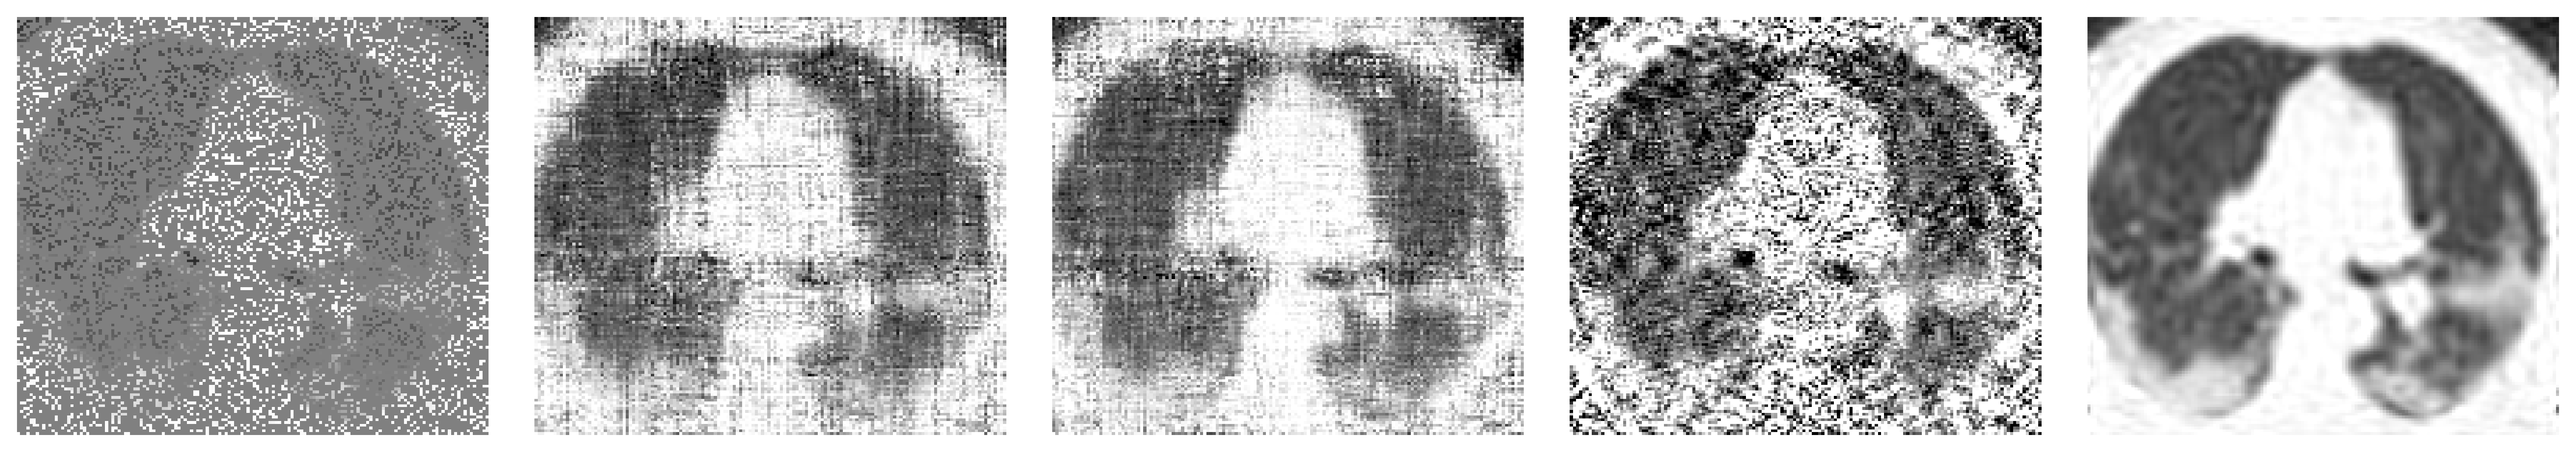

In [2]:
cPath = r'./data/'
signal = []
cfile = os.listdir(cPath)
for f in cfile:
    if f[-1] == 'g':
        im = Image.open(cPath + f)
        im = (np.array(im)-127.5)/255
        signal.append(im)

target_id = 225 #target_id in [225,34,39,72,96,99,104,115]

p = 150
q = 150
p0 = 40
q0 = 40
ri = 20
K = 1
Sscale = 1 
n_fold = 6000
k_fold = 1
        
idx_list, yk_list = generate_kfold_observations(signal[target_id:target_id+1],n_fold,k_fold,K,p,q)
idx_target = list(chain.from_iterable(idx_list[0][i] for i in range(len(idx_list[0]))))
y_target = list(chain.from_iterable(yk_list[0][i] for i in range(len(yk_list[0]))))


m0 = signal[target_id] #raw
        
mask = np.zeros((p, q)) #mask
for idx in idx_target:
    mask.flat[idx] = 1


m0_tilde = RCGD(idx_target,y_target,p,q,ri,eta=0.5) #target


debiased_matrices = signal[target_id+1:target_id+31] 

mean = np.zeros([150,150]) #two-step
for m in debiased_matrices:
    mean += m/len(debiased_matrices)
delta_target = [y_target[i]-mean.flat[idx_target[i]] for i in range(len(y_target))]
delta_hat = RCGD(idx_target,delta_target,p,q,ri,eta=0.5) #finetune

    

R2D2,C2D2 = PCA2D2(debiased_matrices,p0,q0)#representation
m0_feature_finetune = feature_finetune(R2D2,C2D2,idx_target,y_target)


        


tensor = np.zeros((31, p, q)) #tensor
alpha = K * p * q / (n_fold*k_fold*K)
for i, idx in enumerate(idx_target):
        tensor[0].flat[idx] += y_target[i] * alpha

for k in range(1,31):
    tensor[k] = debiased_matrices[k-1]
    
core, factors = tucker(tensor, rank=[np.min([p0*q0,31]), p0, q0])
reconstructed_tensor = tucker_to_tensor((core, factors))
m0_tensor = reconstructed_tensor[0, :, :]



# Set up the figure with specified size and dpi
fig, axes = plt.subplots(1, 5, figsize=[15.5, 3], dpi=400)

# Plot each matrix in a subplot
for i, matrix in enumerate([m0*mask , m0_tilde, mean+delta_hat,m0_tensor, m0_feature_finetune]):
    ax = axes[i]
    sns.heatmap(matrix,cmap="grey",xticklabels=[], yticklabels=[], cbar=False,vmax=0.5,vmin=-0.5,ax=ax)
    ax.axis('off')  # Hide the axis for cleaner visualization

plt.tight_layout()
plt.savefig('main_covid-%d.png'%target_id)